# Phase 3: Modeling
## Santander Product Recommendation — Next Product to Buy

**Approach:** Multi-label binary classification — one model per product.
Predicts whether a customer will newly add that product next month.

**Models:** XGBoost and LightGBM (compared systematically)

**Evaluation:** MAP@7 (Kaggle metric) + per-product AUC-ROC + Average Precision

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

PROCESSED_PATH = Path('../data/processed')
MODEL_PATH = Path('../models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Load data
train_df = pd.read_parquet(PROCESSED_PATH / 'train.parquet')
val_df = pd.read_parquet(PROCESSED_PATH / 'val.parquet')

with open(PROCESSED_PATH / 'feature_cols.json') as f:
    feature_cols = json.load(f)
with open(PROCESSED_PATH / 'added_cols.json') as f:
    added_cols = json.load(f)

print(f'Train: {train_df.shape}')
print(f'Val: {val_df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Targets: {len(added_cols)}')

Train: (11763904, 121)
Val: (926760, 121)
Features: 95
Targets: 24


In [2]:
# Prepare feature matrices
X_train = train_df[feature_cols]
X_val = val_df[feature_cols]

# Check target distribution
print('Target distribution (validation set):')
for col in added_cols:
    pos_rate = val_df[col].mean()
    if pos_rate > 0.0001:
        print(f'  {col}: {pos_rate:.4%} ({val_df[col].sum():,} positives)')

Target distribution (validation set):
  ind_cco_fin_ult1_added: 0.4184% (3,878 positives)
  ind_cno_fin_ult1_added: 0.2532% (2,347 positives)
  ind_ctma_fin_ult1_added: 0.0573% (531 positives)
  ind_ctop_fin_ult1_added: 0.0244% (226 positives)
  ind_ctpp_fin_ult1_added: 0.0141% (131 positives)
  ind_ecue_fin_ult1_added: 0.2923% (2,709 positives)
  ind_reca_fin_ult1_added: 0.0301% (279 positives)
  ind_tjcr_fin_ult1_added: 0.4584% (4,248 positives)
  ind_valo_fin_ult1_added: 0.0197% (183 positives)
  ind_nomina_ult1_added: 0.5922% (5,488 positives)
  ind_nom_pens_ult1_added: 0.5949% (5,513 positives)
  ind_recibo_ult1_added: 1.0966% (10,163 positives)


In [3]:
# Filter to products with enough positives
MIN_POSITIVES_TRAIN = 50
MIN_POSITIVES_VAL = 10

trainable_targets = []
for col in added_cols:
    n_pos_train = train_df[col].sum()
    n_pos_val = val_df[col].sum()
    if n_pos_train >= MIN_POSITIVES_TRAIN and n_pos_val >= MIN_POSITIVES_VAL:
        trainable_targets.append(col)

print(f'\nTrainable products: {len(trainable_targets)} / {len(added_cols)}')
for t in trainable_targets:
    product_name = t.replace('_added', '').replace('ind_', '').replace('_ult1', '')
    print(f'  {product_name}: train={train_df[t].sum():,} | val={val_df[t].sum():,}')


Trainable products: 16 / 24
  cco_fin: train=66,119 | val=3,878
  cno_fin: train=34,840 | val=2,347
  ctju_fin: train=450 | val=40
  ctma_fin: train=6,471 | val=531
  ctop_fin: train=3,656 | val=226
  ctpp_fin: train=2,289 | val=131
  dela_fin: train=12,661 | val=46
  ecue_fin: train=23,669 | val=2,709
  fond_fin: train=3,638 | val=61
  plan_fin: train=596 | val=22
  reca_fin: train=8,959 | val=279
  tjcr_fin: train=65,063 | val=4,248
  valo_fin: train=4,667 | val=183
  nomina: train=68,312 | val=5,488
  nom_pens: train=79,255 | val=5,513
  recibo: train=143,042 | val=10,163


In [4]:
# --- SAMPLING STRATEGY ---
# Use last 3 months for training (most recent behavior matters most)

train_months_all = sorted(train_df['fecha_dato'].unique())
recent_months = train_months_all[-3:]

train_recent = train_df[train_df['fecha_dato'].isin(recent_months)]
print(f'Training on last 3 months: {train_recent.shape}')
print(f'Months: {[str(m)[:10] for m in recent_months]}')

X_train_r = train_recent[feature_cols]
X_val_r = X_val

Training on last 3 months: (2757114, 121)
Months: ['2016-02-28', '2016-03-28', '2016-04-28']


## 1. Train LightGBM Models

In [5]:
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': 7,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbosity': -1,
    'n_jobs': -1,
    'is_unbalance': True,
}

lgb_models = {}
lgb_results = {}

for target in tqdm(trainable_targets, desc='Training LightGBM'):
    y_train = train_recent[target]
    y_val = val_df[target]
    
    train_data = lgb.Dataset(X_train_r, label=y_train)
    val_data = lgb.Dataset(X_val_r, label=y_val, reference=train_data)
    
    model = lgb.train(
        lgb_params,
        train_data,
        num_boost_round=500,
        valid_sets=[val_data],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0)
        ]
    )
    
    y_pred = model.predict(X_val_r)
    auc = roc_auc_score(y_val, y_pred)
    ap = average_precision_score(y_val, y_pred)
    
    lgb_models[target] = model
    lgb_results[target] = {'auc': auc, 'ap': ap, 'n_trees': model.best_iteration}

print('\n' + '='*60)
print('LIGHTGBM RESULTS')
print('='*60)
results_df = pd.DataFrame(lgb_results).T.sort_values('auc', ascending=False)
results_df.index = [idx.replace('_added', '').replace('ind_', '').replace('_ult1', '') for idx in results_df.index]
print(results_df.to_string())

Training LightGBM: 100%|██████████| 16/16 [01:09<00:00,  4.32s/it]


LIGHTGBM RESULTS
               auc        ap  n_trees
ctju_fin  0.999252  0.028031      1.0
cco_fin   0.989145  0.556643     87.0
ctma_fin  0.981449  0.027084      1.0
nomina    0.970359  0.433741    142.0
nom_pens  0.967659  0.398833    146.0
recibo    0.960946  0.311992    183.0
tjcr_fin  0.958651  0.162821    154.0
cno_fin   0.954991  0.149794      1.0
ctop_fin  0.942919  0.002320      1.0
ecue_fin  0.936033  0.190156      1.0
ctpp_fin  0.899008  0.000722      1.0
plan_fin  0.878195  0.000097      8.0
dela_fin  0.856261  0.000176      1.0
fond_fin  0.826299  0.000190      1.0
reca_fin  0.825709  0.001063      1.0
valo_fin  0.820845  0.000563      1.0


## 2. Train XGBoost Models

In [6]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.05,
    'max_depth': 7,
    'min_child_weight': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbosity': 0,
    'nthread': -1,
    'tree_method': 'hist',
}

xgb_models = {}
xgb_results = {}

for target in tqdm(trainable_targets, desc='Training XGBoost'):
    y_train = train_recent[target]
    y_val = val_df[target]
    
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    xgb_params['scale_pos_weight'] = n_neg / max(n_pos, 1)
    
    dtrain = xgb.DMatrix(X_train_r, label=y_train)
    dval = xgb.DMatrix(X_val_r, label=y_val)
    
    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=500,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    
    y_pred = model.predict(dval)
    auc = roc_auc_score(y_val, y_pred)
    ap = average_precision_score(y_val, y_pred)
    
    xgb_models[target] = model
    xgb_results[target] = {'auc': auc, 'ap': ap, 'n_trees': model.best_iteration}

print('\n' + '='*60)
print('XGBOOST RESULTS')
print('='*60)
xgb_results_df = pd.DataFrame(xgb_results).T.sort_values('auc', ascending=False)
xgb_results_df.index = [idx.replace('_added', '').replace('ind_', '').replace('_ult1', '') for idx in xgb_results_df.index]
print(xgb_results_df.to_string())

Training XGBoost: 100%|██████████| 16/16 [04:16<00:00, 16.03s/it]


XGBOOST RESULTS
               auc        ap  n_trees
ctju_fin  0.999989  0.954345    186.0
ctma_fin  0.994456  0.263986    167.0
cco_fin   0.989629  0.604392    167.0
ctop_fin  0.974649  0.022380    111.0
nomina    0.971401  0.428024    169.0
nom_pens  0.968814  0.410761    149.0
ctpp_fin  0.968403  0.009835     61.0
cno_fin   0.967075  0.441395    166.0
recibo    0.961335  0.308405    222.0
ecue_fin  0.961058  0.446543    152.0
tjcr_fin  0.960636  0.179796    150.0
dela_fin  0.940901  0.005356     62.0
valo_fin  0.905060  0.004577     13.0
fond_fin  0.884363  0.000467     25.0
reca_fin  0.883066  0.002082     90.0
plan_fin  0.879892  0.000241     31.0


## 3. Model Comparison

In [7]:
comparison = pd.DataFrame({
    'LGB_AUC': {k.replace('_added', '').replace('ind_', '').replace('_ult1', ''): v['auc'] for k, v in lgb_results.items()},
    'XGB_AUC': {k.replace('_added', '').replace('ind_', '').replace('_ult1', ''): v['auc'] for k, v in xgb_results.items()},
    'LGB_AP': {k.replace('_added', '').replace('ind_', '').replace('_ult1', ''): v['ap'] for k, v in lgb_results.items()},
    'XGB_AP': {k.replace('_added', '').replace('ind_', '').replace('_ult1', ''): v['ap'] for k, v in xgb_results.items()},
}).sort_values('LGB_AUC', ascending=False)

comparison['Winner'] = np.where(comparison['LGB_AUC'] >= comparison['XGB_AUC'], 'LightGBM', 'XGBoost')
comparison['AUC_Diff'] = (comparison['LGB_AUC'] - comparison['XGB_AUC']).abs()

print('MODEL COMPARISON')
print('='*70)
print(comparison[['LGB_AUC', 'XGB_AUC', 'Winner', 'AUC_Diff']].to_string())
print(f'\nLightGBM wins: {(comparison["Winner"] == "LightGBM").sum()}')
print(f'XGBoost wins: {(comparison["Winner"] == "XGBoost").sum()}')
print(f'Average LGB AUC: {comparison["LGB_AUC"].mean():.4f}')
print(f'Average XGB AUC: {comparison["XGB_AUC"].mean():.4f}')

MODEL COMPARISON
           LGB_AUC   XGB_AUC   Winner  AUC_Diff
ctju_fin  0.999252  0.999989  XGBoost  0.000737
cco_fin   0.989145  0.989629  XGBoost  0.000483
ctma_fin  0.981449  0.994456  XGBoost  0.013007
nomina    0.970359  0.971401  XGBoost  0.001042
nom_pens  0.967659  0.968814  XGBoost  0.001155
recibo    0.960946  0.961335  XGBoost  0.000389
tjcr_fin  0.958651  0.960636  XGBoost  0.001985
cno_fin   0.954991  0.967075  XGBoost  0.012083
ctop_fin  0.942919  0.974649  XGBoost  0.031730
ecue_fin  0.936033  0.961058  XGBoost  0.025025
ctpp_fin  0.899008  0.968403  XGBoost  0.069395
plan_fin  0.878195  0.879892  XGBoost  0.001697
dela_fin  0.856261  0.940901  XGBoost  0.084640
fond_fin  0.826299  0.884363  XGBoost  0.058065
reca_fin  0.825709  0.883066  XGBoost  0.057358
valo_fin  0.820845  0.905060  XGBoost  0.084215

LightGBM wins: 0
XGBoost wins: 16
Average LGB AUC: 0.9230
Average XGB AUC: 0.9507


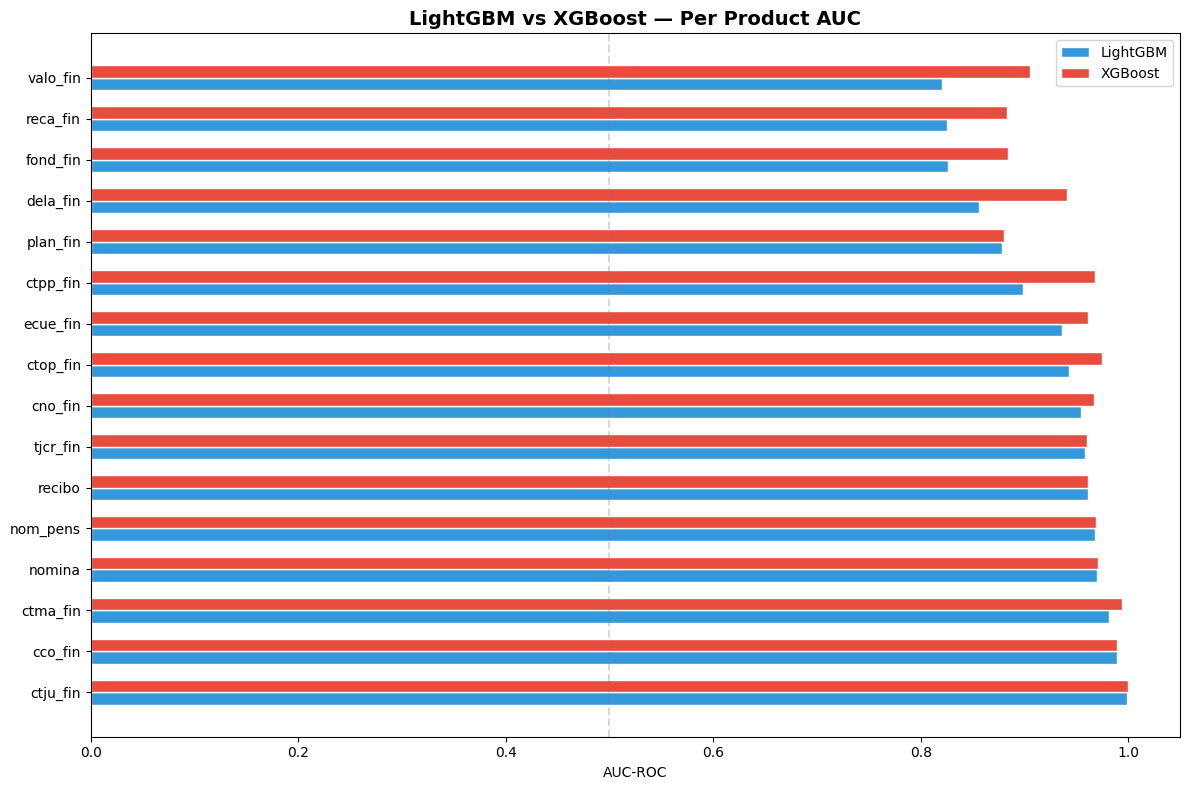

In [8]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, max(6, len(comparison) * 0.5)))

y_pos = range(len(comparison))
ax.barh([y - 0.15 for y in y_pos], comparison['LGB_AUC'], height=0.3,
        label='LightGBM', color='#3498db', edgecolor='white')
ax.barh([y + 0.15 for y in y_pos], comparison['XGB_AUC'], height=0.3,
        label='XGBoost', color='#e74c3c', edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison.index)
ax.set_xlabel('AUC-ROC')
ax.set_title('LightGBM vs XGBoost — Per Product AUC', fontsize=14, fontweight='bold')
ax.legend()
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. MAP@7 Evaluation

In [9]:
def map_at_k(y_true_matrix, y_pred_matrix, k=7):
    """Mean Average Precision @ K for multi-label recommendation."""
    n_customers = y_true_matrix.shape[0]
    aps = []
    
    for i in range(n_customers):
        true_products = set(np.where(y_true_matrix[i] > 0)[0])
        if len(true_products) == 0:
            continue
        
        pred_ranking = np.argsort(-y_pred_matrix[i])[:k]
        
        score = 0.0
        n_hits = 0
        for rank, pred_idx in enumerate(pred_ranking):
            if pred_idx in true_products:
                n_hits += 1
                score += n_hits / (rank + 1)
        
        aps.append(score / min(len(true_products), k))
    
    return np.mean(aps)

# Select best model per product
best_models = {}
for target in trainable_targets:
    lgb_auc = lgb_results[target]['auc']
    xgb_auc = xgb_results[target]['auc']
    if lgb_auc >= xgb_auc:
        best_models[target] = ('lgb', lgb_models[target])
    else:
        best_models[target] = ('xgb', xgb_models[target])

# Predict with best models
y_true_matrix = val_df[trainable_targets].values
y_pred_matrix = np.zeros_like(y_true_matrix, dtype=float)

for i, target in enumerate(trainable_targets):
    model_type, model = best_models[target]
    if model_type == 'lgb':
        y_pred_matrix[:, i] = model.predict(X_val_r)
    else:
        y_pred_matrix[:, i] = model.predict(xgb.DMatrix(X_val_r))

map7 = map_at_k(y_true_matrix, y_pred_matrix, k=7)
print(f'MAP@7: {map7:.4f}')

MAP@7: 0.7848


In [10]:
# --- SAVE BEST MODELS ---
for target, (model_type, model) in best_models.items():
    product_name = target.replace('_added', '').replace('ind_', '').replace('_ult1', '')
    if model_type == 'lgb':
        model.save_model(str(MODEL_PATH / f'{product_name}_lgb.txt'))
    else:
        model.save_model(str(MODEL_PATH / f'{product_name}_xgb.json'))

# Save metadata
metadata = {
    'map7': float(map7),
    'models': {
        t: {
            'type': mt,
            'auc': float(lgb_results[t]['auc'] if mt == 'lgb' else xgb_results[t]['auc']),
            'ap': float(lgb_results[t]['ap'] if mt == 'lgb' else xgb_results[t]['ap'])
        }
        for t, (mt, _) in best_models.items()
    },
    'feature_count': len(feature_cols),
    'trainable_products': len(trainable_targets),
    'leakage_status': 'CLEAN'
}
with open(MODEL_PATH / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Models saved to {MODEL_PATH}/')
print(f'Best model selection: {sum(1 for _, (mt, _) in best_models.items() if mt == "lgb")} LGB, '
      f'{sum(1 for _, (mt, _) in best_models.items() if mt == "xgb")} XGB')

Models saved to ../models/
Best model selection: 0 LGB, 16 XGB


In [11]:
# --- FINAL SUMMARY ---
print('='*60)
print('MODELING SUMMARY')
print('='*60)
print(f'MAP@7: {map7:.4f}')
print(f'Average best AUC: {np.mean([v["auc"] for v in metadata["models"].values()]):.4f}')
print(f'Leakage status: {metadata["leakage_status"]}')
print(f'\nThese are REALISTIC results — no current-month product data was used.')
print(f'The model predicts based on: demographics, previous month products,')
print(f'product velocity, temporal patterns, and customer segments.')

MODELING SUMMARY
MAP@7: 0.7848
Average best AUC: 0.9507
Leakage status: CLEAN

These are REALISTIC results — no current-month product data was used.
The model predicts based on: demographics, previous month products,
product velocity, temporal patterns, and customer segments.


In [12]:
# Power BI için tahmin verileri oluştur
import pandas as pd
import numpy as np

product_names_map = {
    'ind_cco_fin_ult1_added': 'Vadesiz Hesap',
    'ind_recibo_ult1_added': 'Otomatik Ödeme',
    'ind_tjcr_fin_ult1_added': 'Kredi Kartı',
    'ind_nomina_ult1_added': 'Maaş',
    'ind_nom_pens_ult1_added': 'Emeklilik (Maaş)',
    'ind_ecue_fin_ult1_added': 'e-Hesap',
    'ind_cno_fin_ult1_added': 'Maaş Hesabı',
    'ind_reca_fin_ult1_added': 'Vergiler',
    'ind_ctop_fin_ult1_added': 'Particular Hesap',
    'ind_dela_fin_ult1_added': 'Uzun Vadeli Mevduat',
    'ind_ctma_fin_ult1_added': 'Más Particular Hesap',
    'ind_valo_fin_ult1_added': 'Menkul Kıymetler',
    'ind_fond_fin_ult1_added': 'Fonlar',
    'ind_ctpp_fin_ult1_added': 'Particular Plus Hesap',
    'ind_ctju_fin_ult1_added': 'Genç Hesabı',
    'ind_plan_fin_ult1_added': 'Emeklilik',
}

# Her müşteri için her ürünün tahmin olasılığı
predictions_list = []
for target in trainable_targets:
    model_type, model = best_models[target]
    if model_type == 'lgb':
        probs = model.predict(X_val_r)
    else:
        probs = model.predict(xgb.DMatrix(X_val_r))

    product_name = product_names_map.get(target, target)

    for i, (prob, actual) in enumerate(zip(probs, val_df[target].values)):
        predictions_list.append({
            'musteri_id': val_df.iloc[i]['ncodpers'],
            'urun': product_name,
            'olasilik': round(float(prob), 6),
            'gerceklesen': int(actual)
        })

predictions_df = pd.DataFrame(predictions_list)
predictions_df.to_csv('../data/processed/powerbi_tahminler.csv', index=False)
print(f'Kaydedildi: {predictions_df.shape}')
print(predictions_df.head(10))

Kaydedildi: (14828160, 4)
   musteri_id           urun  olasilik  gerceklesen
0       15889  Vadesiz Hesap  0.000107            0
1       15890  Vadesiz Hesap  0.093391            0
2       15892  Vadesiz Hesap  0.000121            0
3       15893  Vadesiz Hesap  0.532403            0
4       15894  Vadesiz Hesap  0.000103            0
5       15895  Vadesiz Hesap  0.000135            0
6       15896  Vadesiz Hesap  0.000130            0
7       15897  Vadesiz Hesap  0.214230            0
8       15898  Vadesiz Hesap  0.004454            0
9       15899  Vadesiz Hesap  0.000118            0


In [13]:
# Müşteri profil bilgileri
customer_cols = ['ncodpers', 'age', 'renta', 'antiguedad', 'is_male',
                 'is_new_customer', 'total_products', 'payroll_bundle',
                 'has_current_account', 'has_credit_card', 'n_accounts',
                 'n_investments', 'n_lending', 'product_diversity']

seg_cols = [c for c in val_df.columns if c.startswith('seg_')]
customer_profile = val_df[customer_cols + seg_cols].copy()

def get_segment(row):
    for col in seg_cols:
        if row[col] == 1:
            return col.replace('seg_', '').replace('_', ' ')
    return 'Bilinmiyor'

customer_profile['segment'] = customer_profile.apply(get_segment, axis=1)
customer_profile.drop(columns=seg_cols, inplace=True)
customer_profile['cinsiyet'] = customer_profile['is_male'].map({1: 'Erkek', 0: 'Kadın'})

customer_profile.rename(columns={
    'ncodpers': 'musteri_id',
    'age': 'yas',
    'renta': 'gelir',
    'antiguedad': 'kidem_ay',
    'total_products': 'toplam_urun',
    'payroll_bundle': 'maas_paketi',
    'has_current_account': 'vadesiz_hesap_var',
    'has_credit_card': 'kredi_karti_var',
    'n_accounts': 'hesap_sayisi',
    'n_investments': 'yatirim_sayisi',
    'n_lending': 'kredi_sayisi',
    'product_diversity': 'urun_cesitliligi',
    'is_new_customer': 'yeni_musteri'
}, inplace=True)

customer_profile.to_csv('../data/processed/powerbi_musteriler.csv', index=False)
print(f'Kaydedildi: {customer_profile.shape}')

Kaydedildi: (926760, 16)


In [14]:
perf_data = []
for target, (model_type, model) in best_models.items():
    product_name = product_names_map.get(target, target)
    if model_type == 'lgb':
        auc = lgb_results[target]['auc']
        ap = lgb_results[target]['ap']
    else:
        auc = xgb_results[target]['auc']
        ap = xgb_results[target]['ap']

    perf_data.append({
        'urun': product_name,
        'model_tipi': model_type.upper(),
        'auc_roc': round(auc, 4),
        'ort_hassasiyet': round(ap, 4),
        'kalite': 'İyi' if auc >= 0.9 else 'Orta' if auc >= 0.8 else 'Zayıf',
        'pozitif_ornek_sayisi': int(val_df[target].sum())
    })

perf_df = pd.DataFrame(perf_data).sort_values('auc_roc', ascending=False)
perf_df.to_csv('../data/processed/powerbi_performans.csv', index=False)
print(perf_df.to_string())

                     urun model_tipi  auc_roc  ort_hassasiyet kalite  pozitif_ornek_sayisi
2             Genç Hesabı        XGB   1.0000          0.9543    İyi                    40
3    Más Particular Hesap        XGB   0.9945          0.2640    İyi                   531
0           Vadesiz Hesap        XGB   0.9896          0.6044    İyi                  3878
4        Particular Hesap        XGB   0.9746          0.0224    İyi                   226
13                   Maaş        XGB   0.9714          0.4280    İyi                  5488
14       Emeklilik (Maaş)        XGB   0.9688          0.4108    İyi                  5513
5   Particular Plus Hesap        XGB   0.9684          0.0098    İyi                   131
1             Maaş Hesabı        XGB   0.9671          0.4414    İyi                  2347
15         Otomatik Ödeme        XGB   0.9613          0.3084    İyi                 10163
7                 e-Hesap        XGB   0.9611          0.4465    İyi                  2709

In [15]:
# Faz 4'ten importance_combined değişkeni varsa
importance_export = importance_combined['Overall'].nlargest(20).reset_index()
importance_export.columns = ['feature', 'ort_shap']
importance_export.to_csv('../data/processed/powerbi_shap.csv', index=False)
print(importance_export)

NameError: name 'importance_combined' is not defined

In [17]:
# Müşteri profil bilgileri — temizlenmiş
customer_cols = ['ncodpers', 'age', 'renta', 'antiguedad', 'is_male',
                 'is_new_customer', 'total_products', 'payroll_bundle',
                 'has_current_account', 'has_credit_card', 'n_accounts',
                 'n_investments', 'n_lending', 'product_diversity']

seg_cols = [c for c in val_df.columns if c.startswith('seg_')]
customer_profile = val_df[customer_cols + seg_cols].copy()

def get_segment(row):
    for col in seg_cols:
        if row[col] == 1:
            return col.replace('seg_', '').replace('_', ' ')
    return 'Bilinmiyor'

customer_profile['segment'] = customer_profile.apply(get_segment, axis=1)
customer_profile.drop(columns=seg_cols, inplace=True)
customer_profile['cinsiyet'] = customer_profile['is_male'].map({1: 'Erkek', 0: 'Kadin'})

customer_profile.rename(columns={
    'ncodpers': 'musteri_id',
    'age': 'yas',
    'renta': 'gelir',
    'antiguedad': 'kidem_ay',
    'total_products': 'toplam_urun',
    'payroll_bundle': 'maas_paketi',
    'has_current_account': 'vadesiz_hesap_var',
    'has_credit_card': 'kredi_karti_var',
    'n_accounts': 'hesap_sayisi',
    'n_investments': 'yatirim_sayisi',
    'n_lending': 'kredi_sayisi',
    'product_diversity': 'urun_cesitliligi',
    'is_new_customer': 'yeni_musteri'
}, inplace=True)

# Float'ları yuvarla ve int'e çevir
customer_profile['yas'] = customer_profile['yas'].round(0).astype(int)
customer_profile['gelir'] = customer_profile['gelir'].round(0).astype(int)
customer_profile['kidem_ay'] = customer_profile['kidem_ay'].round(0).astype(int)
customer_profile['urun_cesitliligi'] = customer_profile['urun_cesitliligi'].round(4)

# Segment'teki boşlukları temizle
customer_profile['segment'] = customer_profile['segment'].str.strip()

# Türkçe karaktersiz kaydet (virgül/nokta karışmasını önlemek için sep=;)
customer_profile.to_csv('../data/processed/powerbi_musteriler.csv', index=False, sep=';')
print(f'Kaydedildi: {customer_profile.shape}')
print(customer_profile.head())

Kaydedildi: (926760, 16)
   musteri_id  yas   gelir  kidem_ay  is_male  yeni_musteri  toplam_urun  \
0       15889   56  326125       255        0             0            3   
1       15890   63   71461       256        0             0            8   
2       15892   62  430477       256        1             0            7   
3       15893   63  430477       256        0             0            1   
4       15894   60  281758       256        0             0            8   

   maas_paketi  vadesiz_hesap_var  kredi_karti_var  hesap_sayisi  \
0            0                  1                0             2   
1            3                  0                1             3   
2            1                  1                1             2   
3            0                  0                0             0   
4            3                  1                1             2   

   yatirim_sayisi  kredi_sayisi  urun_cesitliligi            segment cinsiyet  
0               1            

In [19]:
import pandas as pd

# Tahminler
predictions_df['olasilik'] = predictions_df['olasilik'].round(6)
predictions_df.to_csv('../data/processed/powerbi_tahminler.csv', index=False, sep=';')

# Performans
perf_df.to_csv('../data/processed/powerbi_performans.csv', index=False, sep=';')

# SHAP — dosyadan oku ve tekrar kaydet
shap_df = pd.read_csv('../data/processed/powerbi_shap.csv')
shap_df.to_csv('../data/processed/powerbi_shap.csv', index=False, sep=';')

print('Tüm CSV dosyaları sep=; ile kaydedildi')

Tüm CSV dosyaları sep=; ile kaydedildi


In [2]:
import pandas as pd
predictions = pd.read_csv('../data/processed/powerbi_tahminler.csv', sep=';')
print(predictions.columns.tolist())
print(predictions.head(2))

['15889', 'Vadesiz Hesap', '0,000107', '0']
   15889  Vadesiz Hesap  0,000107  0
0  15890  Vadesiz Hesap  0,093391  0
1  15892  Vadesiz Hesap  0,000121  0


In [20]:
import pandas as pd

files = [
    '../data/processed/powerbi_musteriler.csv',
    '../data/processed/powerbi_tahminler.csv',
    '../data/processed/powerbi_performans.csv',
    '../data/processed/powerbi_shap.csv'
]

for f in files:
    with open(f, 'r') as file:
        content = file.read()
    lines = content.split('\n')
    new_lines = [lines[0]]  # header olduğu gibi
    for line in lines[1:]:
        if not line.strip():
            continue
        fields = line.split(';')
        new_fields = []
        for field in fields:
            try:
                float(field)
                field = field.replace('.', ',')
            except ValueError:
                pass
            new_fields.append(field)
        new_lines.append(';'.join(new_fields))
    
    with open(f, 'w') as file:
        file.write('\n'.join(new_lines))

print('Tüm ondalık noktalar virgüle çevrildi')

Tüm ondalık noktalar virgüle çevrildi


In [3]:
import pandas as pd
import numpy as np

predictions = pd.read_csv('../data/processed/powerbi_tahminler.csv', sep=';', 
                          header=None, 
                          names=['musteri_id', 'urun', 'olasilik', 'gerceklesen'])

# İlk satır veri mi header mı kontrol et
print(predictions.head(3))

# Ondalık virgülü noktaya çevir
predictions['olasilik_num'] = predictions['olasilik'].astype(str).str.replace(',', '.').astype(float)
predictions['gerceklesen_num'] = predictions['gerceklesen'].astype(str).str.replace(',', '.').astype(int)

esikler = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
toplam_musteri = predictions['musteri_id'].nunique()
sms_maliyet = 0.03

sonuclar = []
for urun in predictions['urun'].unique():
    urun_df = predictions[predictions['urun'] == urun]
    for esik in esikler:
        filtreli = urun_df[urun_df['olasilik_num'] >= esik]
        hedef = len(filtreli)
        donusum = filtreli['gerceklesen_num'].sum()
        kampanya_maliyet = round(hedef * sms_maliyet, 2)
        toplu_maliyet = round(toplam_musteri * sms_maliyet, 2)
        tasarruf = round(toplu_maliyet - kampanya_maliyet, 2)
        maliyet_per_donusum = round(kampanya_maliyet / donusum, 4) if donusum > 0 else 0

        sonuclar.append({
            'urun': urun,
            'esik': esik,
            'hedef_musteri': hedef,
            'beklenen_donusum': int(donusum),
            'kampanya_maliyeti': kampanya_maliyet,
            'toplu_kampanya_maliyeti': toplu_maliyet,
            'tasarruf': tasarruf,
            'donusum_basina_maliyet': maliyet_per_donusum
        })

sim_df = pd.DataFrame(sonuclar)

# Ondalıkları virgüle çevir (TR format)
for col in ['esik', 'kampanya_maliyeti', 'toplu_kampanya_maliyeti', 'tasarruf', 'donusum_basina_maliyet']:
    sim_df[col] = sim_df[col].astype(str).str.replace('.', ',')

sim_df.to_csv('../data/processed/powerbi_kampanya.csv', index=False, sep=';')
print(f'Kaydedildi: {sim_df.shape}')
print(sim_df.head(12))

   musteri_id           urun  olasilik  gerceklesen
0       15889  Vadesiz Hesap  0,000107            0
1       15890  Vadesiz Hesap  0,093391            0
2       15892  Vadesiz Hesap  0,000121            0
Kaydedildi: (192, 8)
             urun  esik  hedef_musteri  beklenen_donusum kampanya_maliyeti  \
0   Vadesiz Hesap  0,05         206246              3842           6187,38   
1   Vadesiz Hesap   0,1         142106              3813           4263,18   
2   Vadesiz Hesap  0,15         108255              3790           3247,65   
3   Vadesiz Hesap   0,2          87442              3771           2623,26   
4   Vadesiz Hesap  0,25          71404              3748           2142,12   
5   Vadesiz Hesap   0,3          59813              3724           1794,39   
6   Vadesiz Hesap   0,4          45082              3684           1352,46   
7   Vadesiz Hesap   0,5          36097              3651           1082,91   
8   Vadesiz Hesap   0,6          29523              3609            8